---
## 1. Import Data

## 2. Basic EDA

from ucimlrepo import fetch_ucirepo
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Suppress all deprecation warnings
warnings.filterwarnings('ignore', category=DeprecationWarning)
warnings.filterwarnings('ignore', category=FutureWarning)

banknote_data = fetch_ucirepo(id=267)
X = banknote_data.data.features
y = banknote_data.data.targets

print(f'Samples: {X.shape[0]}, Features: {X.shape[1]}')

## 4. Feature Histograms

## 5. Boxplot by Class

## 6. Correlation Matrix

---
## 7. Prepare Data

---
## 8. Logistic Regression

---
## 9. KNN - Find Best K

C:\Users\ahlaw\AppData\Local\Temp\ipykernel_26084\1225468850.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[i].boxplot([forged, genuine], labels=['Forged', 'Genuine'])
C:\Users\ahlaw\AppData\Local\Temp\ipykernel_26084\1225468850.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[i].boxplot([forged, genuine], labels=['Forged', 'Genuine'])
C:\Users\ahlaw\AppData\Local\Temp\ipykernel_26084\1225468850.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[i].boxplot([forged, genuine], labels=['Forged', 'Genuine'])
C:\Users\ahlaw\AppData\Local\Temp\ipykernel_26084\1225468850.py:8: Matplotli

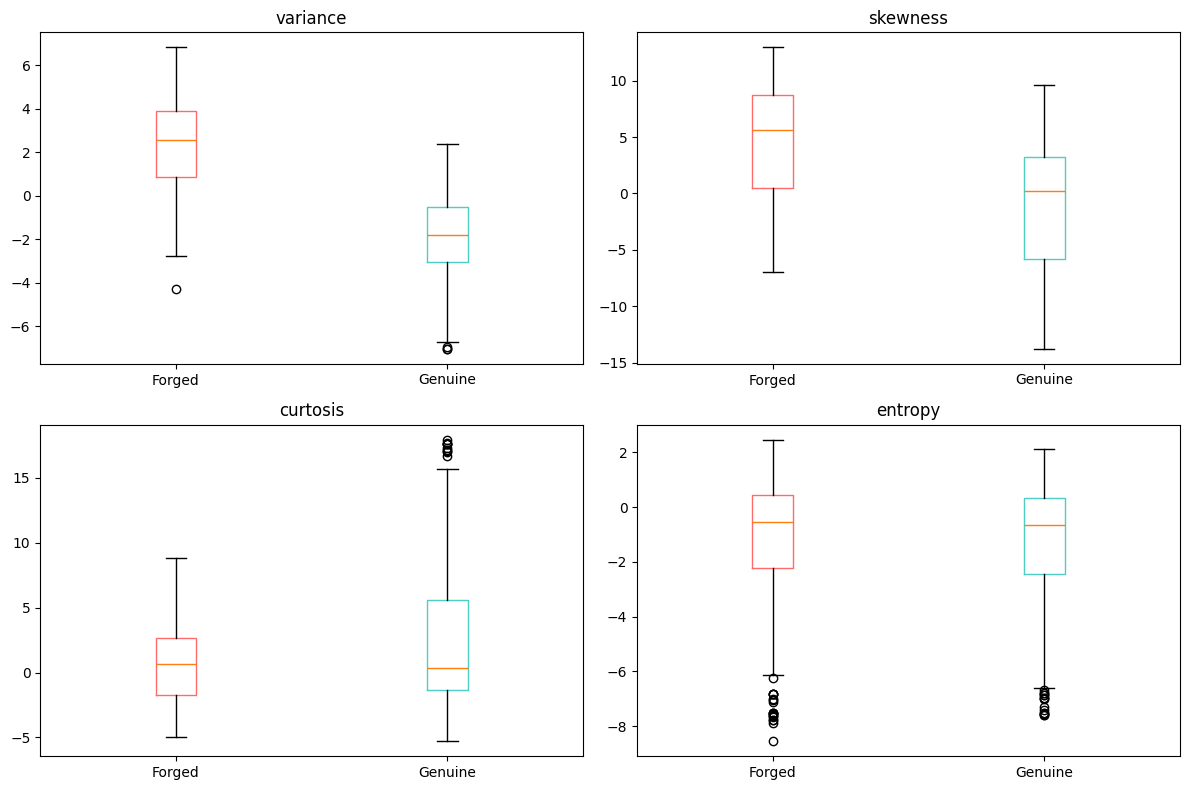

In [75]:
knn = KNeighborsClassifier(n_neighbors=best_k)
knn.fit(X_train_scaled, y_train)

y_pred_knn = knn.predict(X_test_scaled)
y_prob_knn = knn.predict_proba(X_test_scaled)[:, 1]

print(f'KNN (K={best_k}):')
print(f'Accuracy:  {accuracy_score(y_test, y_pred_knn):.4f}')
print(f'Precision: {precision_score(y_test, y_pred_knn):.4f}')
print(f'Recall:    {recall_score(y_test, y_pred_knn):.4f}')
print(f'F1-Score:  {f1_score(y_test, y_pred_knn):.4f}')
print(f'AUC:       {roc_auc_score(y_test, y_prob_knn):.4f}')

cm_knn = confusion_matrix(y_test, y_pred_knn)
print('Confusion Matrix:')
print(cm_knn)

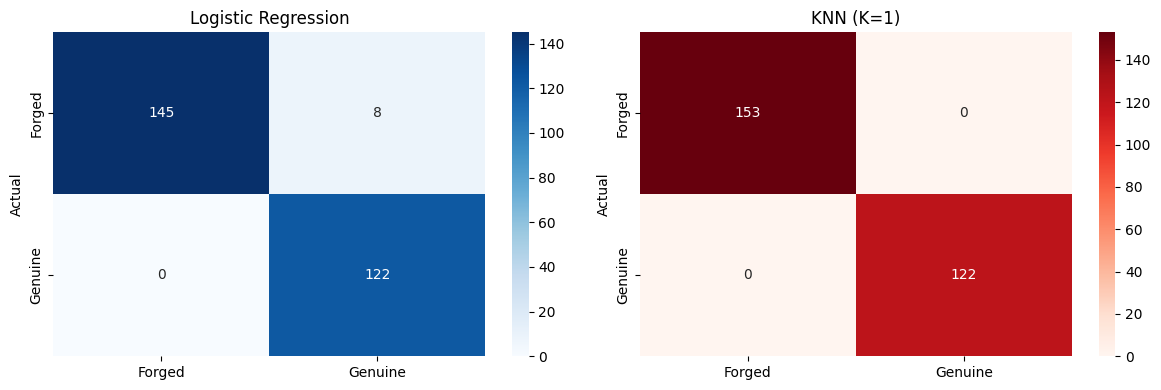

In [60]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', ax=axes[0], xticklabels=['Forged', 'Genuine'], yticklabels=['Forged', 'Genuine'])
axes[0].set_title('Logistic Regression')
axes[0].set_ylabel('Actual')

sns.heatmap(cm_knn, annot=True, fmt='d', cmap='Reds', ax=axes[1], xticklabels=['Forged', 'Genuine'], yticklabels=['Forged', 'Genuine'])
axes[1].set_title(f'KNN (K={best_k})')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()

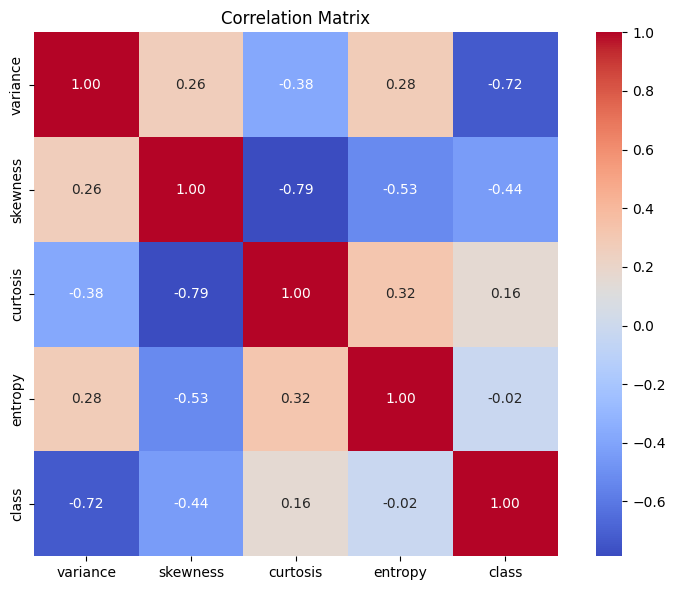

Correlation with target:
class       1.000000
curtosis    0.155883
entropy    -0.023424
skewness   -0.444688
variance   -0.724843
Name: class, dtype: float64


In [76]:
from sklearn.metrics import roc_curve, auc

fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
auc_lr = auc(fpr_lr, tpr_lr)

fpr_knn, tpr_knn, _ = roc_curve(y_test, y_prob_knn)
auc_knn = auc(fpr_knn, tpr_knn)

plt.figure(figsize=(8, 6))
plt.plot(fpr_lr, tpr_lr, label=f'Logistic Reg (AUC={auc_lr:.4f})', linewidth=2)
plt.plot(fpr_knn, tpr_knn, label=f'KNN K={best_k} (AUC={auc_knn:.4f})', linewidth=2)
plt.plot([0, 1], [0, 1], 'r--', label='Random', linewidth=1)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves Comparison')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [62]:
results = {
    'Algorithm': ['Logistic Regression', f'KNN (K={best_k})'],
    'Accuracy': [accuracy_score(y_test, y_pred_lr), accuracy_score(y_test, y_pred_knn)],
    'Precision': [precision_score(y_test, y_pred_lr), precision_score(y_test, y_pred_knn)],
    'Recall': [recall_score(y_test, y_pred_lr), recall_score(y_test, y_pred_knn)],
    'F1-Score': [f1_score(y_test, y_pred_lr), f1_score(y_test, y_pred_knn)],
    'AUC': [auc_lr, auc_knn]
}

df_results = pd.DataFrame(results)
print('\n' + '='*70)
print('FINAL COMPARISON')
print('='*70)
print(df_results.to_string(index=False))
print('='*70)


FINAL COMPARISON
          Algorithm  Accuracy  Precision  Recall  F1-Score      AUC
Logistic Regression  0.970909   0.938462     1.0  0.968254 0.999946
          KNN (K=1)  1.000000   1.000000     1.0  1.000000 1.000000


In [77]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].bar(['Logistic', 'KNN'], df_results['Accuracy'], color=['#4ECDC4', '#FF6B6B'], edgecolor='black')
axes[0].set_title('Accuracy')
axes[0].set_ylim([0.9, 1.0])
axes[0].grid(alpha=0.3, axis='y')

axes[1].bar(['Logistic', 'KNN'], df_results['F1-Score'], color=['#4ECDC4', '#FF6B6B'], edgecolor='black')
axes[1].set_title('F1-Score')
axes[1].set_ylim([0.9, 1.0])
axes[1].grid(alpha=0.3, axis='y')

axes[2].bar(['Logistic', 'KNN'], df_results['AUC'], color=['#4ECDC4', '#FF6B6B'], edgecolor='black')
axes[2].set_title('AUC')
axes[2].set_ylim([0.9, 1.0])
axes[2].grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

Training: 1097 samples
Test: 275 samples
Data scaled!


Logistic Regression: 0.9898 +/- 0.0087
KNN (K=1): 0.9993 +/- 0.0022


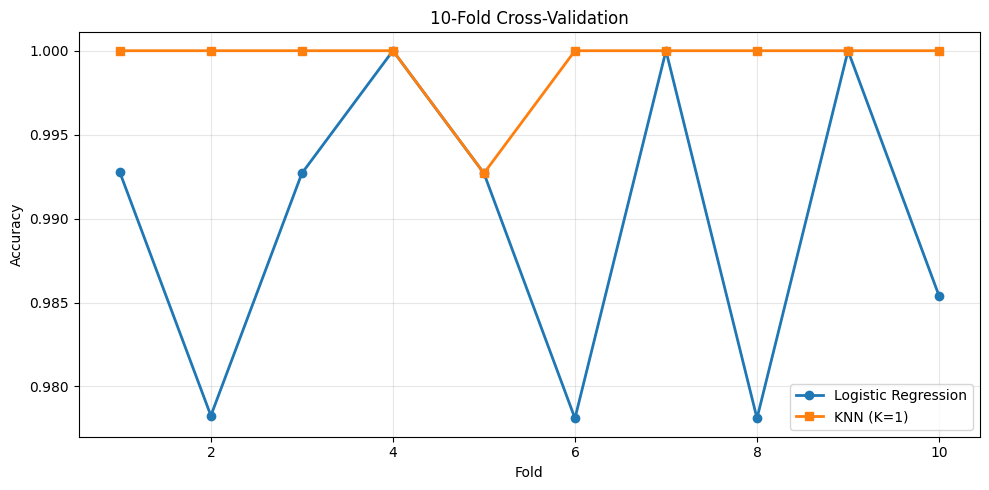

In [64]:
from sklearn.model_selection import cross_val_score, KFold

kfold = KFold(n_splits=10, shuffle=True, random_state=42)

y_flat = y.values.ravel()

lr_cv = cross_val_score(LogisticRegression(max_iter=1000, random_state=42), X, y_flat, cv=kfold, scoring='accuracy')
print(f'Logistic Regression: {lr_cv.mean():.4f} +/- {lr_cv.std():.4f}')

knn_cv = cross_val_score(KNeighborsClassifier(n_neighbors=best_k), X, y_flat, cv=kfold, scoring='accuracy')
print(f'KNN (K={best_k}): {knn_cv.mean():.4f} +/- {knn_cv.std():.4f}')

plt.figure(figsize=(10, 5))
plt.plot(range(1, 11), lr_cv, marker='o', label='Logistic Regression', linewidth=2)
plt.plot(range(1, 11), knn_cv, marker='s', label=f'KNN (K={best_k})', linewidth=2)
plt.xlabel('Fold')
plt.ylabel('Accuracy')
plt.title('10-Fold Cross-Validation')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [78]:
print('\n' + '='*70)
print('FINAL RESULTS')
print('='*70)
print(df_results.to_string(index=False))
print()
print(f'CV - Logistic Regression: {lr_cv.mean():.4f} +/- {lr_cv.std():.4f}')
print(f'CV - KNN (K={best_k}): {knn_cv.mean():.4f} +/- {knn_cv.std():.4f}')
print()
best = 'Logistic Regression' if df_results.loc[0, 'Accuracy'] > df_results.loc[1, 'Accuracy'] else f'KNN (K={best_k})'
print(f'Best Model: {best}')
print('='*70)

LOGISTIC REGRESSION:
Accuracy:  0.9709
Precision: 0.9385
Recall:    1.0000
F1-Score:  0.9683
AUC:       0.9999
Confusion Matrix:
[[145   8]
 [  0 122]]
